## CONV2

Librerias

In [1]:
import os 
import numpy as np  
from PIL import Image  
import tensorflow as tf  
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense  # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping  # Importa el callback

2025-09-26 10:22:10.872489: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-26 10:22:10.872734: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-26 10:22:10.904978: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-26 10:22:11.912385: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Redimensionar imágenes de la banda 13

Este código implementa un pipeline completo de procesamiento de datos para predicción temporal de imágenes satelitales, donde primero redimensiona imágenes de 920x920 a 480x480 píxeles para reducir la carga computacional, luego carga 23 archivos .npy ordenados cronológicamente y aplica normalización individual a cada imagen usando min-max scaling para convertir los valores al rango [0,1], posteriormente crea pares de entrenamiento donde cada imagen en el tiempo t se usa como entrada (X) para predecir la imagen en el tiempo t+1 como salida (y), añadiendo una dimensión de canal con np.newaxis para que las matrices pasen de forma (480,480) a (480,480,1) compatible con redes convolucionales, resultando en arrays X e y con forma (22, 480, 480, 1) que representan 22 ejemplos de entrenamiento donde el modelo aprenderá a predecir el estado futuro de las nubes basándose en su estado actual, lo cual es fundamental para la optimización de plantas fotovoltaicas mediante la predicción del movimiento de nubes en imágenes satelitales.

In [2]:
# Directorio original y reducido
d_original = '/media/smoke/SSD_D0/bandas/banda13/ene_01'
d_reducida = '/media/smoke/SSD_D0/bandas/banda13/ene_01_reducida'


# Función de redimensionado - TAMAÑO PEQUEÑO PARA PRUEBAS
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))  # Redimensiona la imagen
            np.save(os.path.join(d_reducida, filename), img_resized)  # Guarda la imagen redimensionada

# Redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 741 imágenes
Forma de X: (740, 480, 480, 1)
Forma de y: (740, 480, 480, 1)


Este código implementa una red neuronal convolucional secuencial con arquitectura encoder-decoder simétrica que utiliza seis capas Conv2D con filtros que aumentan progresivamente de 16 a 64 canales en las primeras tres capas (extrayendo características cada vez más complejas de las imágenes satelitales) y luego disminuyen simétricamente de 32 a 16 canales para reconstruir la imagen predicha, finalizando con una capa de salida de 1 canal con activación lineal que produce la imagen predicha del tiempo t+1, donde todas las capas usan kernels 3x3 con padding='same' para mantener las dimensiones espaciales constantes (480x480), el modelo se compila con optimizador Adam y función de pérdida MAE (Error Absoluto Medio) que es robusta para datos de radiancia satelital, se entrena durante 10 épocas con lotes de 8 imágenes utilizando EarlyStopping con paciencia de 10 épocas para prevenir sobreentrenamiento y restaurar automáticamente los mejores pesos, creando así un sistema de predicción temporal que aprende patrones espaciales y temporales en el movimiento de nubes para optimización de plantas fotovoltaicas.

In [3]:
# Definir el modelo CNN
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    Conv2D(1, (3, 3), activation='linear', padding='same')
])

model.compile(optimizer='adam', loss='mae', metrics=['mae'])

print("Resumen del modelo:")
model.summary()

# Entrenamiento rápido - solo 3 épocas
print("Iniciando entrenamiento de prueba...")

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X, y,
    epochs=10,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)
print("¡Prueba completada!")
print(f"Pérdida final: {history.history['loss'][-1]:.4f}")

Resumen del modelo:


/home/smoke/datac/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-09-26 10:22:45.097522: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 480, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 480, 480, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,529 (181.75 KB)

 Trainable params: 46,529 (181.75 KB)

 Non-trainable params: 0 (0.00 B)

Iniciando entrenamiento de prueba...
Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - loss: 0.1101 - mae: 0.1101
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - loss: 0.0607 - mae: 0.0607
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - loss: 0.0616 - mae: 0.0616
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - loss: 0.0586 - mae: 0.0586
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - loss: 0.0597 - mae: 0.0597
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - loss: 0.0565 - mae: 0.0565
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - loss: 0.0603 - mae: 0.0603
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - loss: 0.0598 - mae: 0.0598
Epoch 9/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - loss: 0.0597 - mae: 0.0597
Epoch 10/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - loss: 0.0575 - mae: 0.0575
¡Prueba completada!
Pérdida final: 0.0575


24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 876ms/step


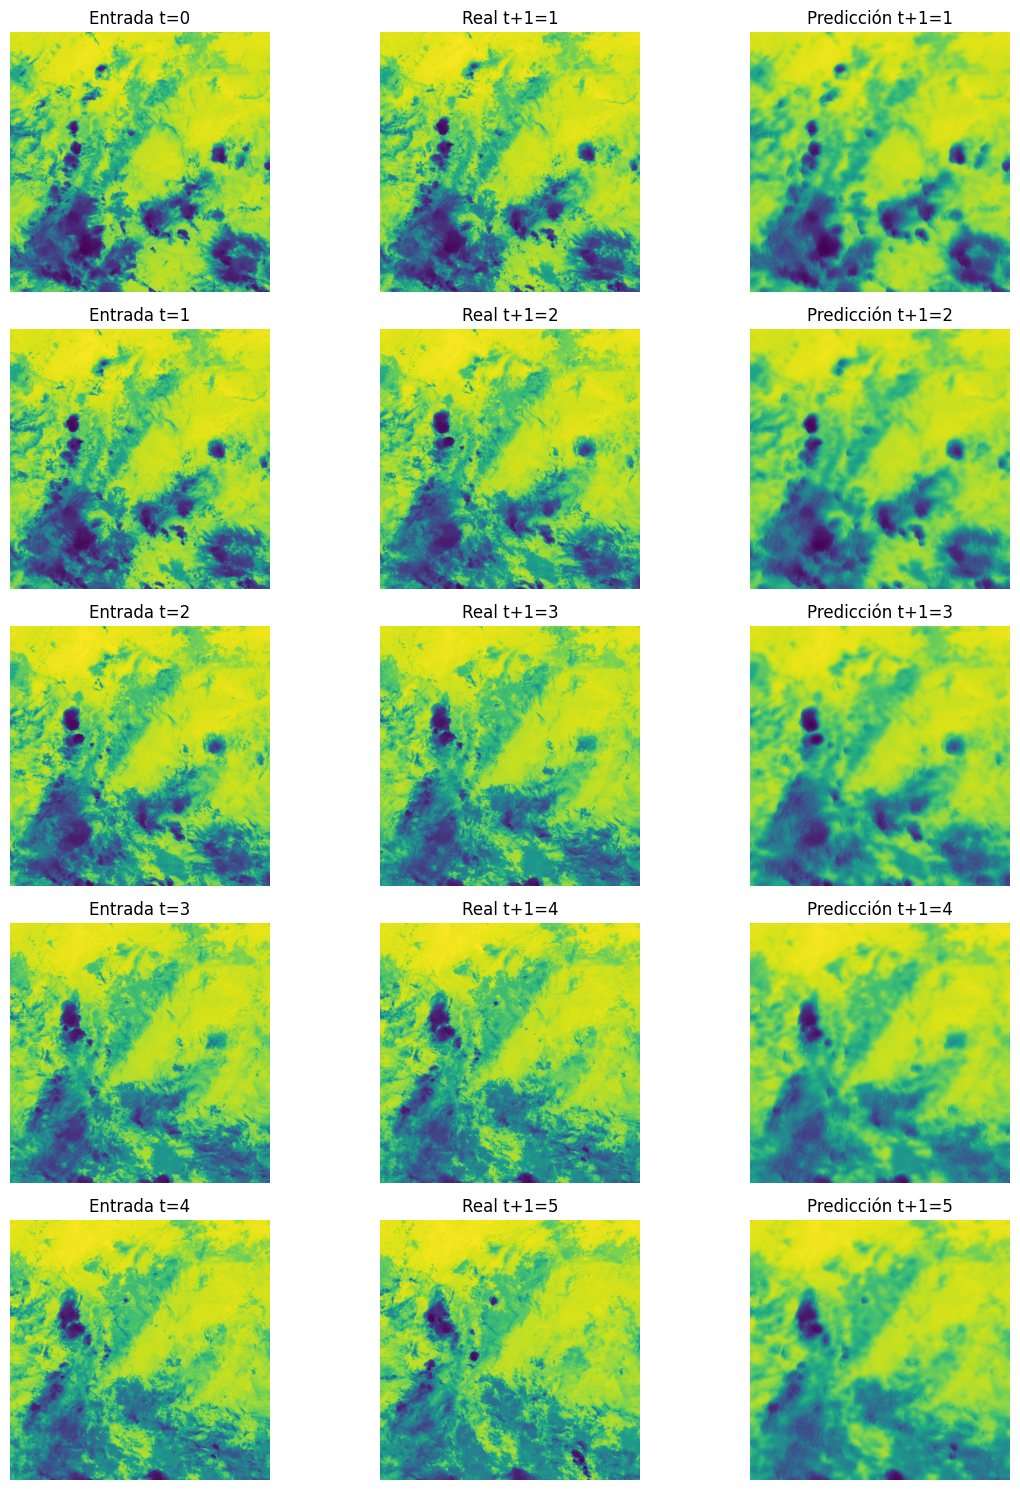

In [4]:
import matplotlib.pyplot as plt

# Selecciona el número de ejemplos a mostrar
n = 5

y_pred = model.predict(X)  # Genera las predicciones

# Muestra imágenes reales vs predichas usando un mapa de color
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y[i, ..., 0], cmap='viridis')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

### Usando 2 canales el 9 y el 13

Este código procesa imágenes satelitales de la banda 9 para crear un segundo conjunto de datos que se combinará con las imágenes de la banda 13, donde primero define los directorios de origen y destino para las imágenes de la banda 9, luego redimensiona estas imágenes de 920x920 a 480x480 píxeles para mantener consistencia dimensional con el primer conjunto de datos, posteriormente carga y ordena cronológicamente los primeros 23 archivos .npy correspondientes a la banda 9, aplica la misma normalización individual min-max scaling utilizada anteriormente para convertir los valores de radiancia al rango [0,1], y finalmente crea los arrays X_1 e y_1 con las secuencias temporales donde cada imagen en el tiempo t predice la imagen en t+1, añadiendo la dimensión de canal necesaria para las redes convolucionales, resultando en un segundo conjunto de datos con forma (22, 480, 480, 1) que representa la misma secuencia temporal pero capturada en una banda espectral diferente (banda 9), lo cual permitirá crear un modelo multicanal que aprovecha información complementaria de ambas bandas espectrales para mejorar la precisión en la predicción del movimiento de nubes.

In [8]:
# Directorio de las nuevas imágenes 920x920 y su destino reducido
d_original_9 = '/media/smoke/SSD_D0/bandas/banda9/ene_01'  # Cambia esta ruta por la ubicación real
d_reducida_9 = '/media/smoke/SSD_D0/bandas/banda9/ene_01_reducida'  # Cambia esta ruta por el destino deseado

# Redimensionar las imágenes 920x920 a 480x480 usando la función existente
resize_npy_images(d_original_9, d_reducida_9, new_size=(480, 480))

# Cargar las 23 imágenes
file_list = sorted([f for f in os.listdir(d_reducida_9) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_9 = [np.load(os.path.join(d_reducida_9, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_9 = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_9]
images_9 = [np.clip(img, 0, 1) for img in images_9]  # Limita los valores al rango [0, 1]
X_1 = np.array(images_9[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_1 = np.array(images_9[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal


Procesando 741 imágenes


Este código implementa un modelo de red neuronal convolucional multicanal que combina información de las bandas espectrales 9 y 13 concatenando los arrays X e X_1 (banda 13) con y e y_1 (banda 9) a lo largo del eje de canales para crear tensores de entrada y salida con forma (22, 480, 480, 2) que contienen información espectral complementaria, luego define una arquitectura encoder-decoder simétrica con seis capas Conv2D que procesan simultáneamente ambos canales espectrales, aumentando progresivamente los filtros de 16 a 64 canales para extraer características complejas y luego reduciéndolos simétricamente hasta una salida de 1 canal con activación lineal, compilando el modelo con optimizador Adam y pérdida MAE para entrenar durante 10 épocas con lotes de 8 ejemplos y EarlyStopping para prevenir sobreentrenamiento, permitiendo así que la red aprenda patrones temporales y espaciales más ricos al aprovechar información de múltiples bandas espectrales para mejorar la precisión en la predicción del movimiento de nubes en aplicaciones de optimización de plantas fotovoltaicas.

In [25]:
# Combinar ambos conjuntos de datos
X_multi = np.concatenate([X, X_1], axis=-1)  # (n, 480, 480, 2)
y_multi = np.concatenate([y, y_1], axis=-1)  # (n, 480, 480, 2)

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X_multi.shape[1:]),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    Conv2D(1, (3, 3), activation='linear', padding='same')
])

model.compile(optimizer='adam', loss='mae', metrics=['mae'])

print("Resumen del modelo:")
model.summary()

# Entrenamiento rápido - solo 3 épocas
print("Iniciando entrenamiento de prueba...")

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_multi, y_multi,
    epochs=10,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)
print("¡Prueba completada!")
print(f"Pérdida final: {history.history['loss'][-1]:.4f}")



Resumen del modelo:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 480, 480, 16)   │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 480, 480, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,673 (182.32 KB)

 Trainable params: 46,673 (182.32 KB)

 Non-trainable params: 0 (0.00 B)

Iniciando entrenamiento de prueba...
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.3974 - mae: 0.3974
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.2422 - mae: 0.2422
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.1369 - mae: 0.1369
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.1339 - mae: 0.1339
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.1307 - mae: 0.1307
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.1020 - mae: 0.1020
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.1097 - mae: 0.1097
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.0997 - mae: 0.0997
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.0939 - mae: 0.0939
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.0937 - mae: 0.0937
¡Prueba completada!
Pérdida final: 0.0937


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step


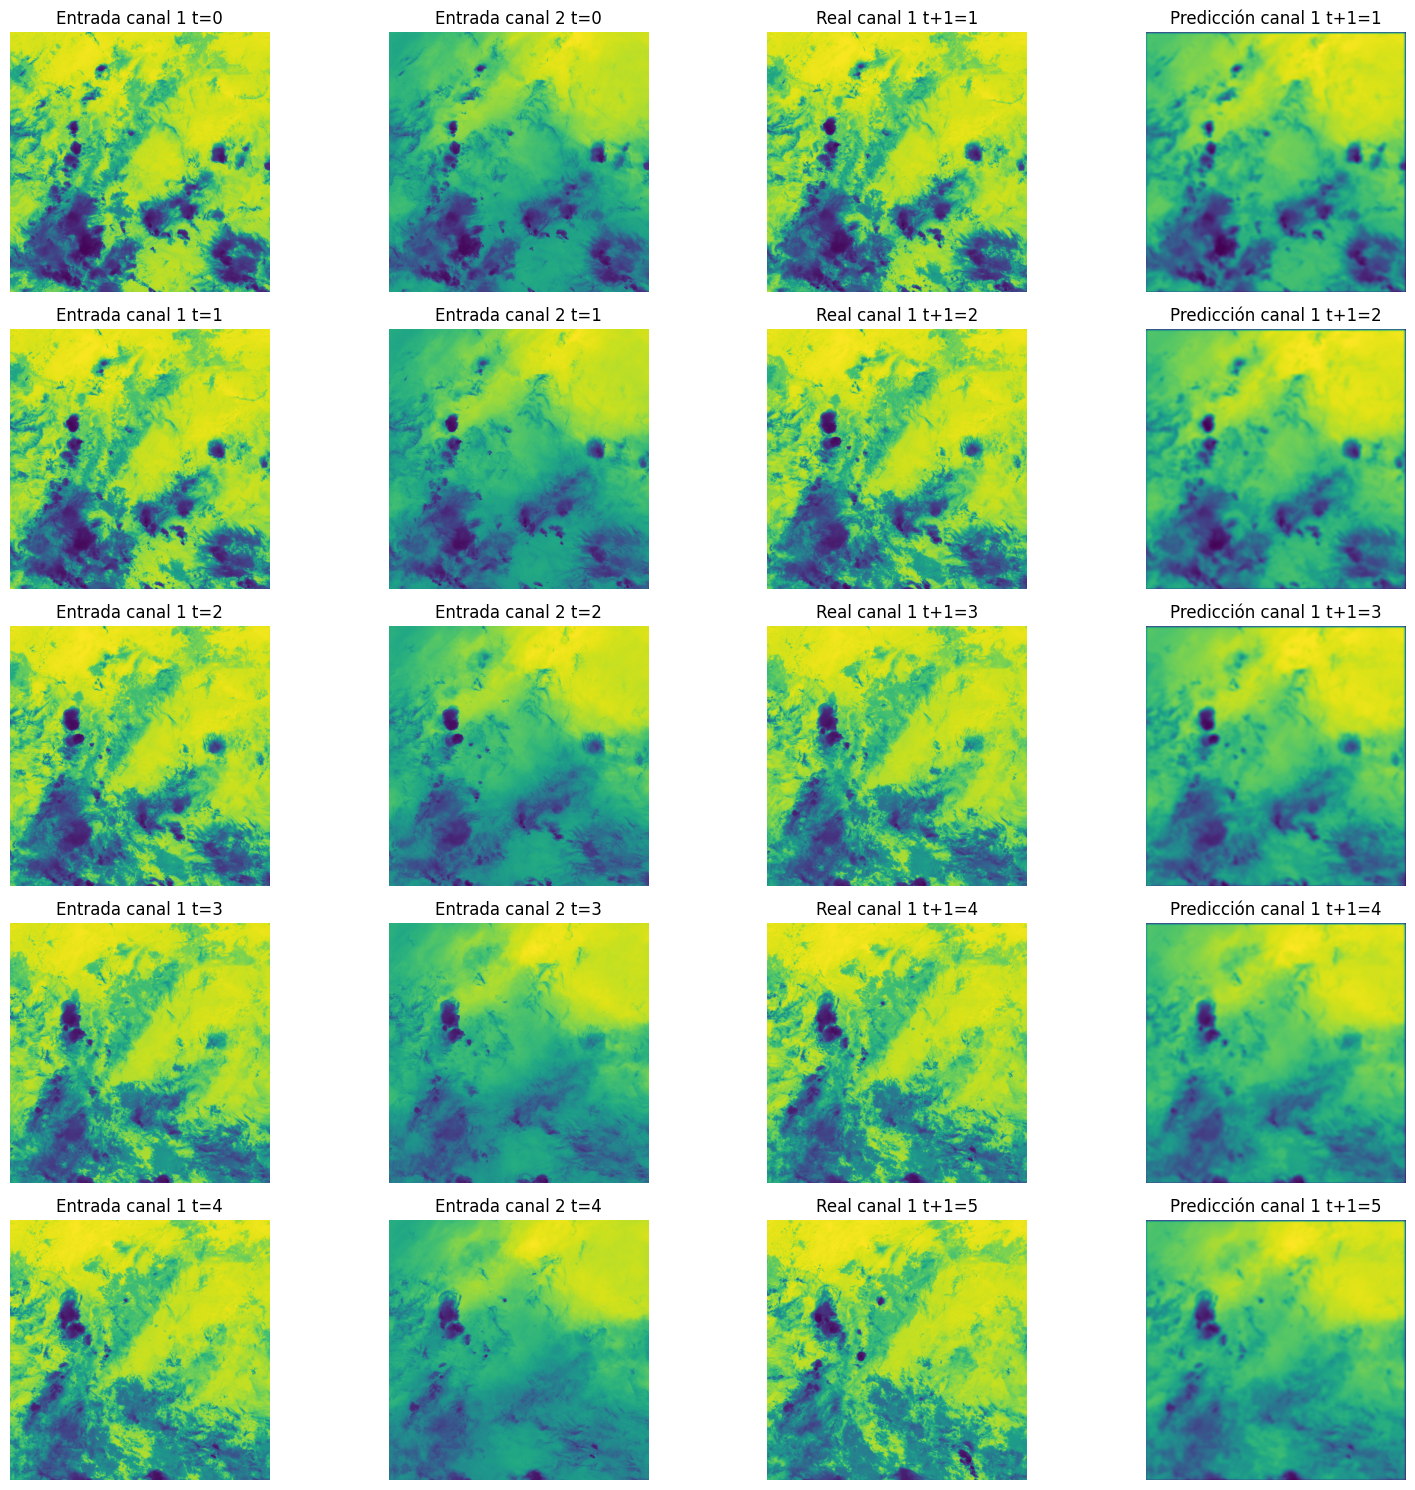

In [26]:
import matplotlib.pyplot as plt

# Generar predicciones con el modelo entrenado
y_pred = model.predict(X_multi)

# Número de ejemplos a mostrar
n = 5

fig, axs = plt.subplots(n, 4, figsize=(16, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X_multi[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada canal 1 t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(X_multi[i, ..., 1], cmap='viridis')
    axs[i, 1].set_title(f'Entrada canal 2 t={i}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_multi[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Real canal 1 t+1={i+1}')
    axs[i, 2].axis('off')

    axs[i, 3].imshow(y_pred[i, ..., 0], cmap='viridis')
    axs[i, 3].set_title(f'Predicción canal 1 t+1={i+1}')
    axs[i, 3].axis('off')

plt.tight_layout()
plt.show()